# Тихонов

# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [5]:
import os
import tempfile
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
seed = 898987

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [6]:
from sklearn.model_selection import train_test_split

target = "salary_in_usd"

X = df.drop(columns=[target, "salary", "salary_currency"])
y = df[target]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, train_size=0.8, random_state=seed
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=seed
)

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)


train: (3004, 8) val: (375, 8) test: (376, 8)


Удалены `salary`, `salary_currency`

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder

categorical_features = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()


def fit_ohe_encoder(data):
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    encoder.fit(data[categorical_features])
    return encoder


def make_ohe_features(data, fitted_encoder):
    encoded_categorical = fitted_encoder.transform(data[categorical_features])
    numeric = data[numeric_features].to_numpy(dtype=float)
    feature_names = numeric_features + fitted_encoder.get_feature_names_out(categorical_features).tolist()
    return pd.DataFrame(
        np.hstack([numeric, encoded_categorical]),
        columns=feature_names,
        index=data.index,
    )


def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def regression_metrics(y_true, y_pred):
    return {
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
    }


train_encoder = fit_ohe_encoder(X_train)
X_train_ohe = make_ohe_features(X_train, train_encoder)
X_val_ohe = make_ohe_features(X_val, train_encoder)
X_test_ohe = make_ohe_features(X_test, train_encoder)

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])
train_val_encoder = fit_ohe_encoder(X_train_val)
X_train_val_ohe = make_ohe_features(X_train_val, train_val_encoder)
X_test_ohe_final = make_ohe_features(X_test, train_val_encoder)

boosting_results = []

linear_model = LinearRegression()
start = time.perf_counter()
linear_model.fit(X_train_ohe, y_train)
linear_fit_time = time.perf_counter() - start

start = time.perf_counter()
linear_pred = linear_model.predict(X_test_ohe)
linear_predict_time = time.perf_counter() - start
linear_test_metrics = regression_metrics(y_test, linear_pred)

boosting_results.append(
    {
        "model": "LinearRegression",
        "best_params": "-",
        "fit_time_sec": linear_fit_time,
        "predict_time_sec": linear_predict_time,
        **linear_test_metrics,
    }
)

print("MAPE: ", linear_test_metrics["MAPE"])
print("RMSE: ", linear_test_metrics["RMSE"])


MAPE:  0.3274791890165933
RMSE:  48157.63608110331


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [8]:
from sklearn.model_selection import ParameterGrid
from xgboost.sklearn import XGBRegressor

params = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.08],
    "n_estimators": [300, 500],
    "gamma": [0, 0.1],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8],
    "reg_lambda": [1, 3],
}

xgb_param_grid = list(ParameterGrid(params))
print("Number of XGBoost candidates:", len(xgb_param_grid))


def tune_encoded_regressor(model_cls, param_grid, fixed_params=None):
    fixed_params = fixed_params or {}
    search_results = []

    for candidate_params in param_grid:
        model = model_cls(**candidate_params, **fixed_params)
        start = time.perf_counter()
        model.fit(X_train_ohe, y_train)
        fit_time = time.perf_counter() - start

        start = time.perf_counter()
        val_pred = model.predict(X_val_ohe)
        predict_time = time.perf_counter() - start
        val_metrics = regression_metrics(y_val, val_pred)

        search_results.append(
            {
                "params": candidate_params,
                "val_MAPE": val_metrics["MAPE"],
                "val_RMSE": val_metrics["RMSE"],
                "fit_time_sec": fit_time,
                "predict_time_sec": predict_time,
            }
        )

    search_results = pd.DataFrame(search_results).sort_values("val_RMSE")
    best_params = search_results.iloc[0]["params"]
    final_model = model_cls(**best_params, **fixed_params)

    start = time.perf_counter()
    final_model.fit(X_train_val_ohe, y_train_val)
    final_fit_time = time.perf_counter() - start

    start = time.perf_counter()
    test_pred = final_model.predict(X_test_ohe_final)
    final_predict_time = time.perf_counter() - start

    return best_params, final_model, regression_metrics(y_test, test_pred), final_fit_time, final_predict_time, search_results


xgb_best_params, xgb_model, xgb_test_metrics, xgb_fit_time, xgb_predict_time, xgb_search_results = tune_encoded_regressor(
    XGBRegressor,
    xgb_param_grid,
    {
        "objective": "reg:squarederror",
        "random_state": seed,
        "n_jobs": -1,
    },
)


Number of XGBoost candidates: 144


In [9]:
boosting_results.append(
    {
        "model": "XGBRegressor",
        "best_params": xgb_best_params,
        "fit_time_sec": xgb_fit_time,
        "predict_time_sec": xgb_predict_time,
        **xgb_test_metrics,
    }
)

print("Best params:", xgb_best_params)
print("Fit time, sec:", xgb_fit_time)
print("Predict time, sec:", xgb_predict_time)
print("MAPE: ", xgb_test_metrics["MAPE"])
print("RMSE: ", xgb_test_metrics["RMSE"])

Best params: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.08, 'max_depth': 4, 'n_estimators': 500, 'reg_lambda': 1, 'subsample': 0.8}
Fit time, sec: 0.9053667919997679
Predict time, sec: 0.00625370799934899
MAPE:  0.30539050698280334
RMSE:  46500.1787523446


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [10]:
from catboost import CatBoostRegressor

params = {
    "depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.08],
    "iterations": [300, 500],
    "l2_leaf_reg": [3, 5],
}

catboost_param_grid = list(ParameterGrid(params))
print("Number of CatBoost candidates:", len(catboost_param_grid))

cat_ohe_best_params, cat_ohe_model, cat_ohe_test_metrics, cat_ohe_fit_time, cat_ohe_predict_time, cat_ohe_search_results = tune_encoded_regressor(
    CatBoostRegressor,
    catboost_param_grid,
    {
        "loss_function": "RMSE",
        "random_seed": seed,
        "verbose": False,
        "allow_writing_files": False,
    },
)


Number of CatBoost candidates: 36


In [11]:
boosting_results.append(
    {
        "model": "CatBoostRegressor_OHE",
        "best_params": cat_ohe_best_params,
        "fit_time_sec": cat_ohe_fit_time,
        "predict_time_sec": cat_ohe_predict_time,
        **cat_ohe_test_metrics,
    }
)

print("Best params:", cat_ohe_best_params)
print("Fit time, sec:", cat_ohe_fit_time)
print("Predict time, sec:", cat_ohe_predict_time)
print("MAPE: ", cat_ohe_test_metrics["MAPE"])
print("RMSE: ", cat_ohe_test_metrics["RMSE"])

Best params: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.08}
Fit time, sec: 0.2521438749990921
Predict time, sec: 0.002955582998765749
MAPE:  0.30146209687923603
RMSE:  44617.88054927144


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [12]:
from catboost import Pool

cat_feature_indices = [X_train.columns.get_loc(feature) for feature in categorical_features]
train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
val_pool = Pool(X_val, y_val, cat_features=cat_feature_indices)
train_val_pool = Pool(X_train_val, y_train_val, cat_features=cat_feature_indices)
test_pool = Pool(X_test, y_test, cat_features=cat_feature_indices)

cat_pool_search_results = []

for candidate_params in catboost_param_grid:
    model = CatBoostRegressor(
        **candidate_params,
        loss_function="RMSE",
        random_seed=seed,
        verbose=False,
        allow_writing_files=False,
    )
    start = time.perf_counter()
    model.fit(train_pool)
    fit_time = time.perf_counter() - start

    start = time.perf_counter()
    val_pred = model.predict(val_pool)
    predict_time = time.perf_counter() - start
    val_metrics = regression_metrics(y_val, val_pred)

    cat_pool_search_results.append(
        {
            "params": candidate_params,
            "val_MAPE": val_metrics["MAPE"],
            "val_RMSE": val_metrics["RMSE"],
            "fit_time_sec": fit_time,
            "predict_time_sec": predict_time,
        }
    )

cat_pool_search_results = pd.DataFrame(cat_pool_search_results).sort_values("val_RMSE")
cat_pool_best_params = cat_pool_search_results.iloc[0]["params"]
cat_pool_model = CatBoostRegressor(
    **cat_pool_best_params,
    loss_function="RMSE",
    random_seed=seed,
    verbose=False,
    allow_writing_files=False,
)

start = time.perf_counter()
cat_pool_model.fit(train_val_pool)
cat_pool_fit_time = time.perf_counter() - start

start = time.perf_counter()
cat_pool_pred = cat_pool_model.predict(test_pool)
cat_pool_predict_time = time.perf_counter() - start
cat_pool_test_metrics = regression_metrics(y_test, cat_pool_pred)

boosting_results.append(
    {
        "model": "CatBoostRegressor_native_cat",
        "best_params": cat_pool_best_params,
        "fit_time_sec": cat_pool_fit_time,
        "predict_time_sec": cat_pool_predict_time,
        **cat_pool_test_metrics,
    }
)

print("Best params:", cat_pool_best_params)
print("Fit time, sec:", cat_pool_fit_time)
print("Predict time, sec:", cat_pool_predict_time)
print("MAPE: ", cat_pool_test_metrics["MAPE"])
print("RMSE: ", cat_pool_test_metrics["RMSE"])

Best params: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.08}
Fit time, sec: 0.8665055830006168
Predict time, sec: 0.0005611249998764833
MAPE:  0.34010331348421785
RMSE:  45342.39339414384


**Ответ:** В этом прогоне CatBoost с `Pool` и явным указанием категориальных признаков не стал лучше версии с one-hot encoding по качеству: RMSE получился около 45.3k против 44.6k у OHE, а MAPE - около 0.340 против 0.301. Зато `Pool`-версия предсказывает быстрее: примерно 0.0006 секунды против 0.003 секунды. По времени обучения нативная обработка категориальных признаков здесь медленнее из-за внутренней обработки категорий. На этом небольшом датасете one-hot encoding оказался удачнее по метрикам, хотя `Pool` удобнее тем, что не требует вручную кодировать категории.


## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [13]:
from lightgbm import LGBMRegressor

params = {
    "max_depth": [3, 5, -1],
    "learning_rate": [0.03, 0.05, 0.08],
    "n_estimators": [300, 500],
    "num_leaves": [15, 31],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8],
    "reg_lambda": [1, 3],
}

lgbm_param_grid = list(ParameterGrid(params))
print("Number of LightGBM candidates:", len(lgbm_param_grid))

lgbm_best_params, lgbm_model, lgbm_test_metrics, lgbm_fit_time, lgbm_predict_time, lgbm_search_results = tune_encoded_regressor(
    LGBMRegressor,
    lgbm_param_grid,
    {
        "random_state": seed,
        "n_jobs": -1,
        "verbose": -1,
    },
)


Number of LightGBM candidates: 144


In [14]:
boosting_results.append(
    {
        "model": "LGBMRegressor",
        "best_params": lgbm_best_params,
        "fit_time_sec": lgbm_fit_time,
        "predict_time_sec": lgbm_predict_time,
        **lgbm_test_metrics,
    }
)

results_df = pd.DataFrame(boosting_results).sort_values("RMSE")
display(results_df)

print("Best params:", lgbm_best_params)
print("Fit time, sec:", lgbm_fit_time)
print("Predict time, sec:", lgbm_predict_time)
print("MAPE: ", lgbm_test_metrics["MAPE"])
print("RMSE: ", lgbm_test_metrics["RMSE"])

,model,best_params,fit_time_sec,predict_time_sec,MAPE,RMSE
2,CatBoostRegressor_OHE,"{'depth': 6, 'iterations': 500, 'l2_leaf_reg':...",0.252144,0.002956,0.301462,44617.880549
3,CatBoostRegressor_native_cat,"{'depth': 6, 'iterations': 500, 'l2_leaf_reg':...",0.866506,0.000561,0.340103,45342.393394
4,LGBMRegressor,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.499462,0.001570,0.325110,45623.866821
1,XGBRegressor,"{'colsample_bytree': 0.8, 'gamma': 0.1, 'learn...",0.905367,0.006254,0.305391,46500.178752
0,LinearRegression,-,0.017554,0.000853,0.327479,48157.636081


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'num_leaves': 15, 'reg_lambda': 3, 'subsample': 0.8}
Fit time, sec: 0.49946249999993597
Predict time, sec: 0.0015696669997851131
MAPE:  0.3251102467313689
RMSE:  45623.86682105784


## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** После удаления признаков `salary` и `salary_currency` все бустинги улучшили линейную регрессию по RMSE: линейная модель дала около 48.2k, а бустинги - около 44.6-46.5k. Лучшее качество в моем прогоне получилось у `CatBoostRegressor` после one-hot encoding: RMSE около 44.6k и MAPE около 0.301. Худший RMSE среди бустингов показал `XGBRegressor` - около 46.5k, а худший MAPE - CatBoost с нативными категориальными признаками, около 0.340
По скорости финального обучения на этой выборке быстрее всего оказался CatBoost на OHE, затем LightGBM, CatBoost с `Pool` и XGBoost. По скорости предсказания быстрее всего оказался CatBoost с `Pool`, но в целом все работают быстро

Гиперпараметры похожи по смыслу, но называются по-разному у XGBoost и LightGBM явно настраивались глубина/сложность дерева, темп обучения, число деревьев, subsample/colsample и регуляризация у CatBoost ключевыми были `depth`, `learning_rate`, `iterations`, `l2_leaf_reg`. Для всех использовал неглубокие деревья, небольшой `learning_rate` и много итераций


# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [15]:
import pandas as pd
from pathlib import Path

seed = 7876876987
ratings_url = "https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true"
ratings = pd.read_excel("sample_matrix.xlsx")
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [16]:
ratings = ratings.T
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [17]:
ratings.columns = ratings.loc["user"].astype(int)
ratings = ratings.drop(index="user")
ratings.index.name = "artist"
ratings.head()

user,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
artist,,,,,,,,,,,,,,,,,,,,,
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [18]:
ratings = ratings.fillna(0).astype(float)
ratings.sample(random_state=seed)

user,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
artist,,,,,,,,,,,,,,,,,,,,,
bon jovi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.01649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [19]:
from sklearn.cluster import KMeans

km_raw = KMeans(n_clusters=5, random_state=seed, n_init=10)
labels_raw = km_raw.fit_predict(ratings)
raw_labels = pd.Series(labels_raw, index=ratings.index, name="cluster")

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [20]:
raw_cluster_sizes = raw_labels.value_counts().sort_index()
raw_cluster_sizes

cluster
0    115
1      1
2      1
3    882
4      1
Name: count, dtype: int64

**Ответ:** Кластеризация получилась почти бесполезной: размеры кластеров вышли `115, 1, 1, 882, 1`, то есть KMeans отделил несколько одиночных выбросов и почти всех остальных исполнителей сложил в один большой кластер. Так происходит потому, что исходные векторы очень разреженные, а евклидово расстояние сильно зависит от нормы вектора: популярные исполнители с большой суммарной долей прослушиваний становятся выбросами, а не представителями жанров

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [21]:
single_cluster_ids = raw_cluster_sizes[raw_cluster_sizes == 1].index
single_artists = raw_labels[raw_labels.isin(single_cluster_ids)].sort_values()
single_artists

artist
日dir en grey    1
niИ             2
the beatles     4
Name: cluster, dtype: int32

Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [22]:
artist_stats = pd.DataFrame(
    {
        "listeners_share": (ratings > 0).mean(axis=1),
        "mean_share": ratings.mean(axis=1),
        "sum_share": ratings.sum(axis=1),
    }
)

print("Статистика одиночных кластеров:")
display(artist_stats.loc[single_artists.index].join(single_artists))

print("Топ по доле слушателей:")
display(artist_stats.sort_values(["listeners_share", "mean_share"], ascending=False).head(15))

Статистика одиночных кластеров:


,listeners_share,mean_share,sum_share,cluster
artist,,,,
日dir en grey,0.0102,0.001689,8.444680,1
niИ,0.1182,0.006470,32.351575,2
the beatles,0.3342,0.018369,91.844883,4


Топ по доле слушателей:


,listeners_share,mean_share,sum_share
artist,,,
the beatles,0.3342,0.018369,91.844883
radiohead,0.2778,0.011851,59.256073
deathcab for cutie,0.1862,0.006543,32.716688
coldplay,0.1682,0.006030,30.151904
modest mouse,0.1628,0.005876,29.381284
sufjan stevens,0.1292,0.004969,24.845181
dylan. bob,0.1262,0.004963,24.812551
red hot clili peppers,0.1258,0.003994,19.972262
pink fluid,0.1256,0.004909,24.545514


**Ответ:**  Beatles выделяются потому, что это самый массовый исполнитель в матрице: их слушали примерно 33.4% пользователей, средняя доля прослушивания около 0.0184, суммарная доля около 91.8. Это заметно больше, чем у большинства артистов, поэтому без нормализации KMeans видит прежде всего масштаб/популярность, а не схожесть профиля аудитории

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [32]:
from sklearn.preprocessing import normalize

ratings_norm = pd.DataFrame(
    normalize(ratings, norm="l2"),
    index=ratings.index,
    columns=ratings.columns,
)
ratings_norm.head()

user,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
artist,,,,,,,,,,,,,,,,,,,,,
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.000000,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.008120,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.085361,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.144628,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [33]:
km = KMeans(n_clusters=5, random_state=seed, n_init=10)
labels = km.fit_predict(ratings_norm)
cluster_labels = pd.Series(labels, index=ratings_norm.index, name="cluster")
cluster_sizes = cluster_labels.value_counts().sort_index()
cluster_sizes

cluster
0     79
1    162
2    133
3    140
4    486
Name: count, dtype: int64

**Ответ** После нормализации размеры стали намного адекватнее: `79, 162, 133, 140, 486`. Один большой кластер всё еще есть, но одиночные выбросы исчезли. Такая кластеризация уже полезная она группирует исполнителей по похожему распределению слушателей, а не по абсолютной популярности

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [25]:
from scipy.spatial.distance import cosine

centroids = km.cluster_centers_
centroid_neighbors = {}

for cluster_id, centroid in enumerate(centroids):
    cluster_artists = ratings_norm.index[labels == cluster_id]
    distances = ratings_norm.loc[cluster_artists].apply(lambda row: cosine(row, centroid), axis=1)
    centroid_neighbors[cluster_id] = distances.nsmallest(10).index.tolist()

centroid_neighbors_5 = pd.DataFrame(centroid_neighbors)
centroid_neighbors_5

,0,1,2,3,4
0,nas,fall out boy,brand new,the beatles,radiohead
1,jay-z,the all-americian rejects,blink-182,the rolling stones,the arcade fire
2,kanye west,paramore,alkaline trio,dylan. bob,the shins
3,lupe the gorilla,kelly clarkson,against me!,who,sufjan stevens
4,a tribe called quest,john mayer,underoath,led zeppelin.,belle and sebastian
5,the roots featuring d'angelo,the fray,descendents,miles davis.,broken social scene
6,gangstarr,maroon5,new found glory,simon and garfunkel,the pixies
7,little brother,dashboard confesssional,less than jake,"young, neil",animal collective
8,lil' wayne,somethings corporate,thrice,pink fluid,modest mouse
9,murs and 9th wonder,coldplay,chiodos,velvet underground,spoon


**Ответ:** Кластеры получились интерпретируемыми. Кластер 0 похож на hip-hop/rap (`nas`, `jay-z`, `kanye west`), кластер 1 - на mainstream pop/soft alternative (`fall out boy`, `paramore`, `kelly clarkson`, `john mayer`), кластер 2 - на pop-punk/emo/hardcore (`brand new`, `blink-182`, `underoath`), кластер 3 - на classic rock и близкую классику (`the beatles`, `the rolling stones`, `bob dylan`, `led zeppelin`), кластер 4 - на indie/alternative (`radiohead`, `the arcade fire`, `sufjan stevens`, `modest mouse`). Смысл кластеров музыкально аудиторный рядом оказываются исполнители, которых слушают похожие пользователи

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

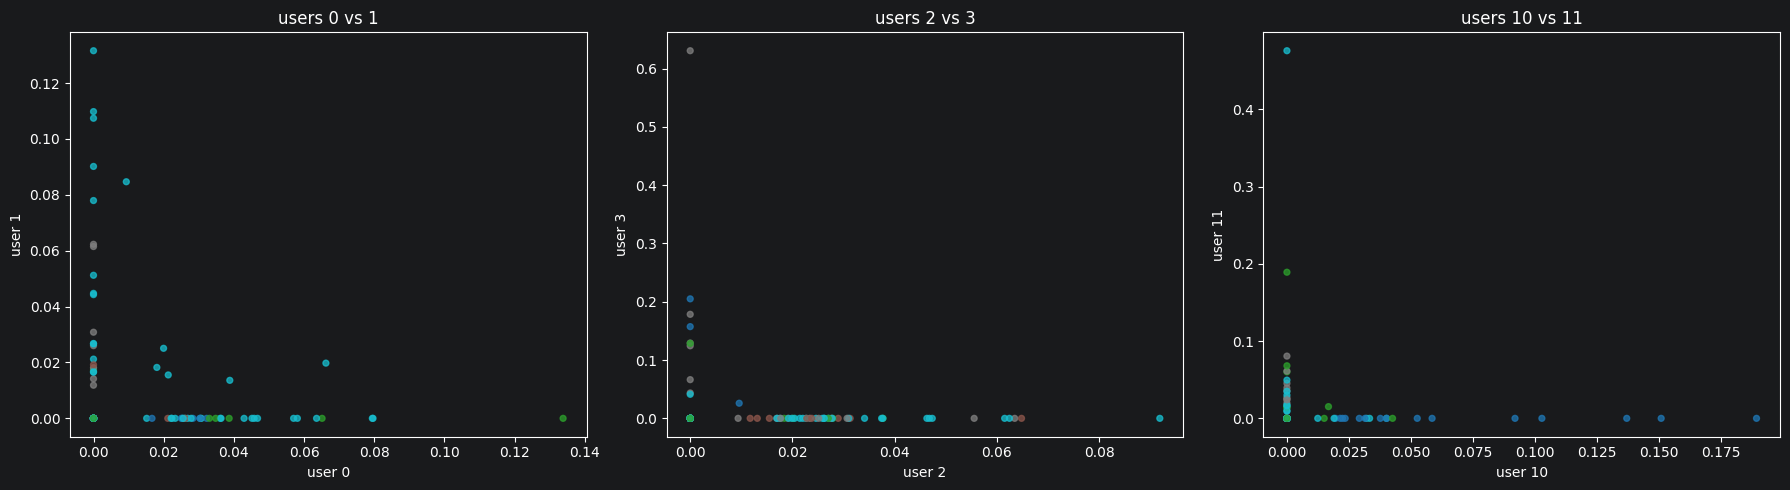

In [26]:
import matplotlib.pyplot as plt

feature_pairs = [
    (ratings_norm.columns[0], ratings_norm.columns[1]),
    (ratings_norm.columns[2], ratings_norm.columns[3]),
    (ratings_norm.columns[10], ratings_norm.columns[11]),
]

fig, axes = plt.subplots(1, len(feature_pairs), figsize=(18, 5))
for ax, (x_col, y_col) in zip(axes, feature_pairs):
    ax.scatter(
        ratings_norm[x_col],
        ratings_norm[y_col],
        c=labels,
        cmap="tab10",
        s=18,
        alpha=0.75,
    )
    ax.set_xlabel(f"user {x_col}")
    ax.set_ylabel(f"user {y_col}")
    ax.set_title(f"users {x_col} vs {y_col}")

fig.tight_layout()

**Ответ:** Обычные scatter-графики по двум пользователям почти не отражают разделение на кластеры. Данные очень разреженные и высокоразмерные: один отдельный пользователь -- слабый признак для описания исполнителя, поэтому на случайных парах координат большинство точек лежит около нуля и сильно накладывается. Кластеры существуют в общей структуре 5000 признаков, а не в одной двух выбранных координатах

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

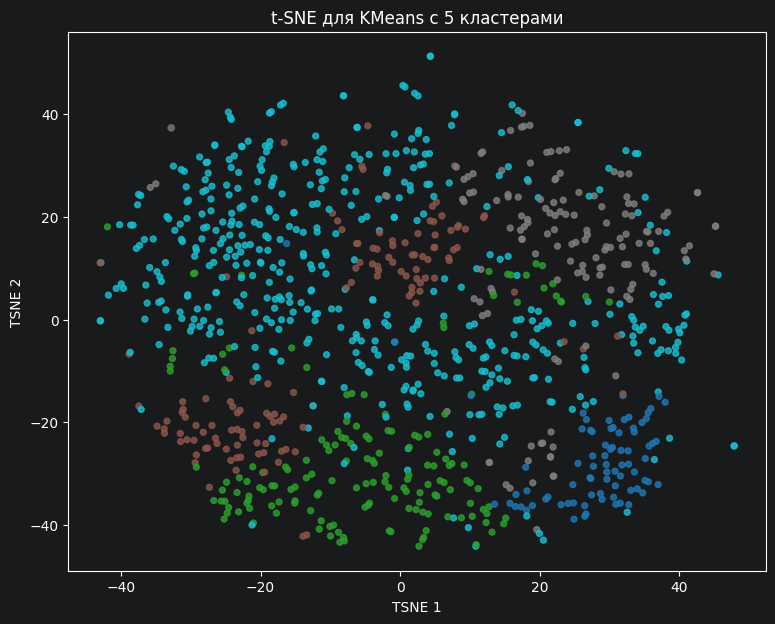

In [27]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=seed,
    perplexity=30,
    learning_rate=200,
    init="random",
    metric="cosine",
)
tsne_embedding = tsne.fit_transform(ratings_norm)

plt.figure(figsize=(9, 7))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=labels, cmap="tab10", s=18, alpha=0.8)
plt.title("t-SNE для KMeans с 5 кластерами")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2");

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

Best n_clusters: 99
Best cosine silhouette: 0.02559865180603253


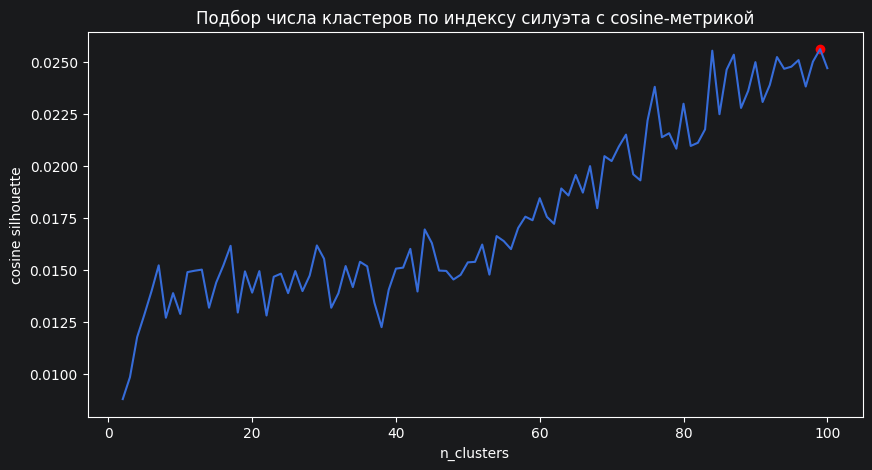

In [28]:
from sklearn.metrics import silhouette_score

silhouette_results = []
for n_clusters in range(2, 101):
    candidate_km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    candidate_labels = candidate_km.fit_predict(ratings_norm)
    score = silhouette_score(ratings_norm, candidate_labels, metric="cosine")
    silhouette_results.append({"n_clusters": n_clusters, "silhouette": score})

silhouette_results = pd.DataFrame(silhouette_results)
best_n_clusters = int(silhouette_results.loc[silhouette_results["silhouette"].idxmax(), "n_clusters"])
best_silhouette = float(silhouette_results["silhouette"].max())

print("Best n_clusters:", best_n_clusters)
print("Best cosine silhouette:", best_silhouette)

auto_km = KMeans(n_clusters=best_n_clusters, random_state=seed, n_init=10)
labels_best = auto_km.fit_predict(ratings_norm)
best_cluster_labels = pd.Series(labels_best, index=ratings_norm.index, name="cluster")

plt.figure(figsize=(10, 5))
plt.plot(silhouette_results["n_clusters"], silhouette_results["silhouette"])
plt.scatter([best_n_clusters], [best_silhouette], color="red")
plt.xlabel("n_clusters")
plt.ylabel("cosine silhouette")
plt.title("Подбор числа кластеров по индексу силуэта с cosine-метрикой");


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [29]:
best_centroid_rows = []

for cluster_id, centroid in enumerate(auto_km.cluster_centers_):
    cluster_artists = ratings_norm.index[labels_best == cluster_id]
    distances = ratings_norm.loc[cluster_artists].apply(lambda row: cosine(row, centroid), axis=1)
    best_centroid_rows.append(
        {
            "cluster": cluster_id,
            "size": len(cluster_artists),
            "top_artists": ", ".join(distances.nsmallest(10).index.tolist()),
        }
    )

best_centroid_table = pd.DataFrame(best_centroid_rows).sort_values("cluster")
best_cluster_sizes = best_cluster_labels.value_counts().sort_index()

display(best_cluster_sizes.describe())
display(best_centroid_table)

count    99.000000
mean     10.101010
std       4.599235
min       3.000000
25%       7.000000
50%       9.000000
75%      12.000000
max      26.000000
Name: count, dtype: float64

,cluster,size,top_artists
0,0,5,"tйlйpopmusik, lamb, niИ, röyksopp, the cinemat..."
1,1,22,"led zeppelin., the rolling stones, the beatles..."
2,2,8,"less than jake, sum41, reel big fish, goldfing..."
3,3,7,"the thermals, the replacements, ted leo and th..."
4,4,4,"the rocket summer, the format, jack’s mannequi..."
...,...,...,...
94,94,11,"j dilla, the loopdigga, mf doom & madlib as ma..."
95,95,8,"plain white t＇s, the all-americian rejects, he..."
96,96,7,"zimmer, lord of the rings, apocalyptica, trans..."
97,97,7,"godspeed you!, black emperor, mogwai, do make ..."


**Ответ:** Оптимум по индексу силуэта с cosine-метрикой получился при 99 кластерах, но сам индекс всё равно маленький, около 0.026. Значит, структура есть, но кластеры не разделены резко. По сравнению с 5 кластерами смысл стал более детальным: широкие группы распались на поджанры и более узкие аудитории. Например, отдельно видны классический рок вокруг `led zeppelin`/`the rolling stones`/`the beatles`, hip-hop вокруг `jay-z`/`nas`/`kanye west`, indie/alternative вокруг `radiohead`/`the arcade fire`, электронная музыка вокруг `amon tobin`/`boards of canada`/`aphex twin`, классическая музыка вокруг Моцарта/Вивальди/Баха/Шопена. Общий смысл прежний - схожесть аудиторий, но гранулярность стала намного выше


Сделайте t-SNE визуализацию полученной кластеризации.

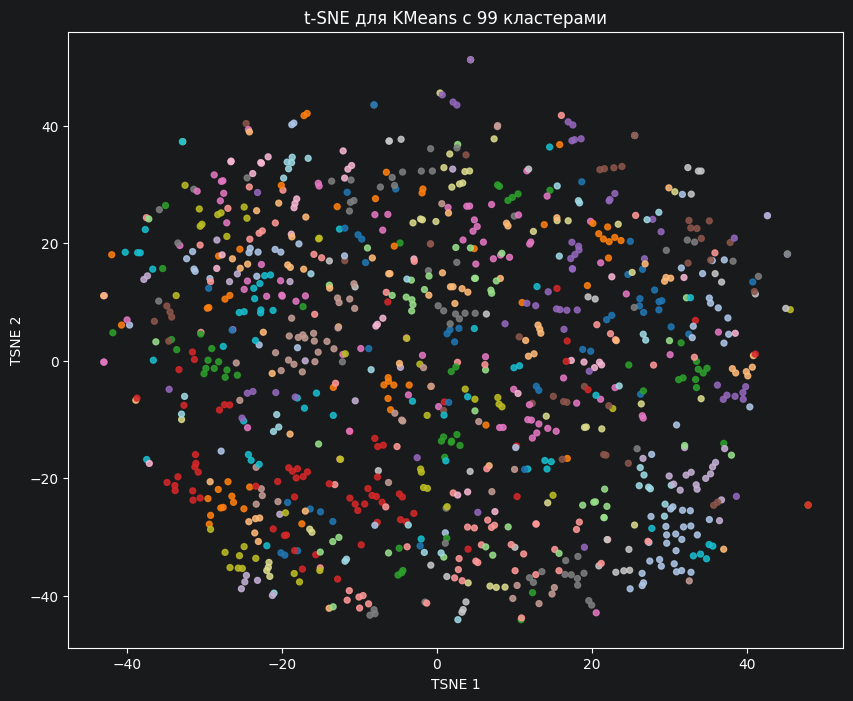

In [30]:
plt.figure(figsize=(10, 8))
plt.scatter(
    tsne_embedding[:, 0],
    tsne_embedding[:, 1],
    c=labels_best,
    cmap="tab20",
    s=18,
    alpha=0.85,
)
plt.title(f"t-SNE для KMeans с {best_n_clusters} кластерами")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2");

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

,cluster,size,top_artists
42,42,9,"Вольфганг Амадей Моцарт, ВИВАЛЬДИ, Бах Иоганн ..."


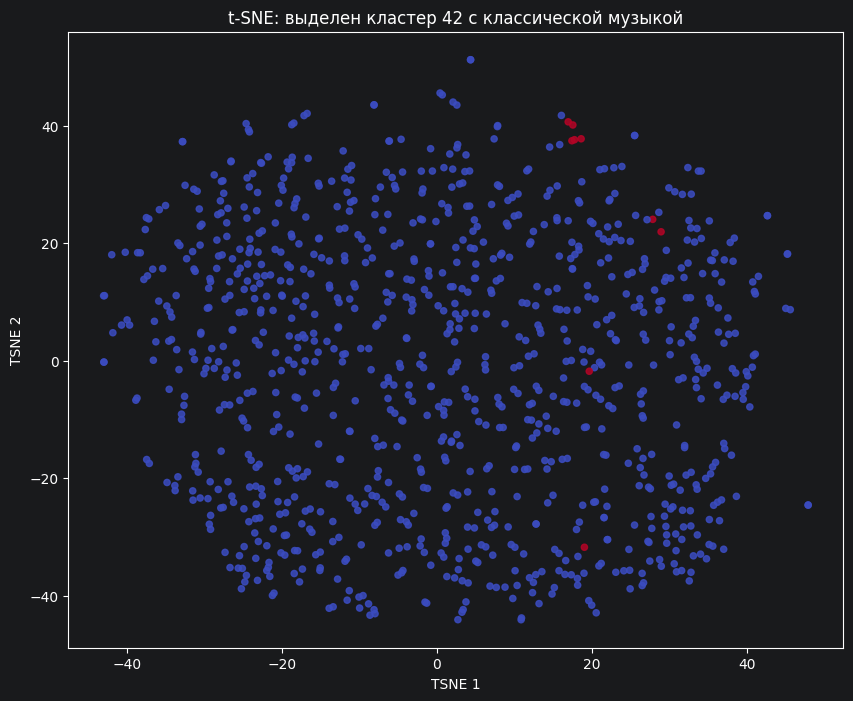

In [31]:
reference_artist = "Вольфганг Амадей Моцарт"
interesting_cluster = int(best_cluster_labels.loc[reference_artist])

plt.figure(figsize=(10, 8))
plt.scatter(
    tsne_embedding[:, 0],
    tsne_embedding[:, 1],
    c=(labels_best == interesting_cluster),
    cmap="coolwarm",
    s=20,
    alpha=0.85,
)
plt.title(f"t-SNE: выделен кластер {interesting_cluster} с классической музыкой")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2");

best_centroid_table.query("cluster == @interesting_cluster")

**Ответ:** При 99 кластерах общая t-SNE-картинка перегружена цветами, поэтому по ней трудно читать все группы сразу. Если подсветить один интересный кластер, например кластер с классической музыкой, видно, что он не образует один компактный и хорошо отделенный остров: точки разбросаны по нескольким локальным областям и смешиваются с остальными исполнителями. Это согласуется с низким значением silhouette: кластер имеет некоторый смысл по исходным признакам, но в двумерной t-SNE-визуализации отделяется слабо
